<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/11_Principal_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Principal Component Analysis (PCA)

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Materi
PCA adalah teknik reduksi dimensi yang menggunakan eigendecomposition atau SVD untuk menemukan sumbu utama (principal components) di mana data memiliki varians terbesar. PCA memungkinkan kita menyederhanakan data yang kompleks menjadi struktur yang lebih ringan tanpa kehilangan informasi statistik yang penting.

### Topik yang Dibahas:
1. Konsep Varians dan Kovarians dalam PCA
2. Prosedur PCA (Mean Centering, Matriks Kovarians, Eigendecomposition)
3. Interpretasi Eigenvalues (Scree Plot)
4. Proyeksi Data ke Ruang Dimensi Rendah


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Simulasi Data (Dua variabel yang saling berkorelasi)
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 2 * x + np.random.normal(0, 0.5, 100)
data = np.column_stack((x, y))

# 2. Prosedur PCA Manual
# Langkah A: Mean Centering
data_centered = data - np.mean(data, axis=0)

# Langkah B: Matriks Kovarians
C = (data_centered.T @ data_centered) / (len(data) - 1)

# Langkah C: Eigendecomposition
evals, evecs = np.linalg.eig(C)

print("Nilai Eigen:", evals)
print("Vektor Eigen (Sumbu Utama):\n", evecs)


Nilai Eigen: [0.04522181 4.0696904 ]
Vektor Eigen (Sumbu Utama):
 [[-0.89794091 -0.44011603]
 [ 0.44011603 -0.89794091]]


***
## Interpretasi Geometris PCA

Vektor eigen pertama menunjukkan arah varians terbesar. Data diproyeksikan ke vektor ini untuk mengurangi dimensi menjadi satu komponen utama (PC1).




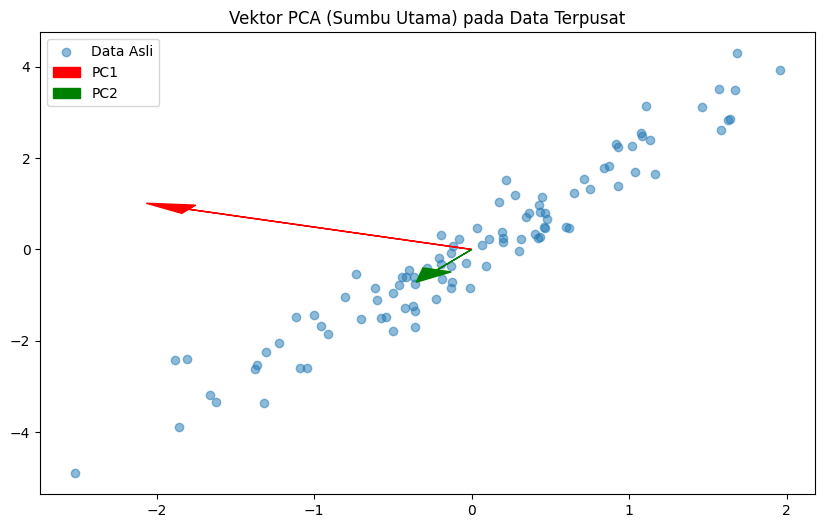

In [2]:
# Proyeksi data ke Komponen Utama pertama (PC1)
pc1 = data_centered @ evecs[:, 0]

plt.figure(figsize=(10, 6))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5, label='Data Asli')
plt.arrow(0, 0, evecs[0, 0]*2, evecs[1, 0]*2, color='red', head_width=0.2, label='PC1')
plt.arrow(0, 0, evecs[0, 1]*0.5, evecs[1, 1]*0.5, color='green', head_width=0.2, label='PC2')
plt.title('Vektor PCA (Sumbu Utama) pada Data Terpusat')
plt.legend()
plt.show()


***
## Analisis Varians yang Dijelaskan

Penting untuk memahami berapa persen informasi yang dipertahankan. Kita menggunakan rasio nilai eigen untuk menentukan seberapa banyak varians yang ditangkap oleh setiap komponen.

Varians yang dijelaskan oleh PC1: 1.10 persen
Varians yang dijelaskan oleh PC2: 98.90 persen


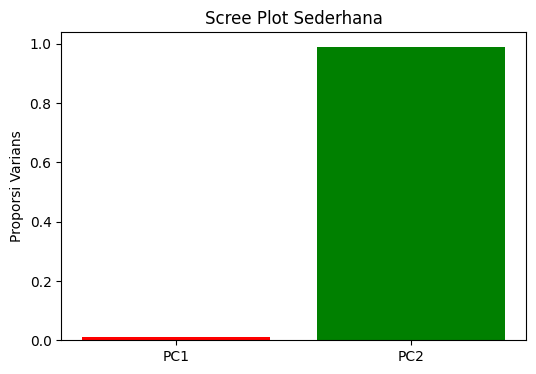

In [3]:
var_explained = evals / np.sum(evals)
print(f"Varians yang dijelaskan oleh PC1: {var_explained[0]*100:.2f} persen")
print(f"Varians yang dijelaskan oleh PC2: {var_explained[1]*100:.2f} persen")

plt.figure(figsize=(6, 4))
plt.bar(['PC1', 'PC2'], var_explained, color=['red', 'green'])
plt.ylabel('Proporsi Varians')
plt.title('Scree Plot Sederhana')
plt.show()
